## Merge LMP Yearly Averages with Pnode Locations

Merges `va_lmp_yearly_avg_all.csv` with `va_pnode_ids_final_full.csv` to add latitude and longitude to each pnode, then adds census tract via spatial join.

In [33]:
import pandas as pd
import geopandas as gpd
from pathlib import Path

DATA_DIR = next(
    p / "data" for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "data").exists()
)

usa_dir = DATA_DIR / "processed" / "usa_data"
processed_dir = DATA_DIR / "processed" / "pjm_lmp_data"

In [34]:
# Load data
lmp = pd.read_csv(processed_dir / "va_lmp_yearly_avg_load.csv")
pnodes = pd.read_csv(usa_dir / "va_pnode_ids_final_full.csv")

print("LMP shape:", lmp.shape)
print("Pnode shape:", pnodes.shape)
print("\nLMP columns:", lmp.columns.tolist())
print("\nPnode columns:", pnodes.columns.tolist())

LMP shape: (8886, 9)
Pnode shape: (1152, 6)

LMP columns: ['year', 'pnode_id', 'pnode_name', 'type', 'avg_total_lmp', 'avg_energy', 'avg_congestion', 'avg_loss', 'hours']

Pnode columns: ['substation_name', 'latitude', 'longitude', 'pnode_match', 'pnode_id', 'type']


In [35]:
# Merge on pnode_id, adding only latitude and longitude
merged = lmp.merge(
    pnodes[["pnode_id", "latitude", "longitude"]],
    on="pnode_id",
    how="left"
)

print("Merged shape:", merged.shape)
print("Rows missing lat/lon:", merged["latitude"].isna().sum())
merged.head()

Merged shape: (8886, 11)
Rows missing lat/lon: 0


,year,pnode_id,pnode_name,type,avg_total_lmp,avg_energy,avg_congestion,avg_loss,hours,latitude,longitude
0,2015,48907,GOSHEN,LOAD,32.056865,33.339051,-2.223583,0.941397,8760,37.968345,-79.509225
1,2015,48908,GOSHEN,LOAD,32.058873,33.339051,-2.223549,0.943371,8760,37.968345,-79.509225
2,2015,49283,ROCKRIDG,LOAD,40.155350,33.339051,5.483211,1.333088,8760,37.798442,-79.415567
3,2015,49284,ROCKRIDG,LOAD,40.144136,33.339051,5.483212,1.321872,8760,37.798442,-79.415567
4,2015,49285,ROCKRIDG,LOAD,36.113239,33.339051,1.556303,1.217885,8760,37.798442,-79.415567


Note: from the raw LMP data, some pnodes have the same name but different IDs and slightly different prices. This reflects that one subtstation may have multiple LOAD pnodes and is not an error. 

In [36]:
# Load Virginia census tract shapefile from 2016 (pre-treatment)
census = gpd.read_file(
    DATA_DIR / "raw" / "census_data" / "tl_2016_51_tract" / "tl_2016_51_tract.shp"
)
print("Census CRS:", census.crs)
print("Census columns:", census.columns.tolist())

Census CRS: EPSG:4269
Census columns: ['STATEFP', 'COUNTYFP', 'TRACTCE', 'GEOID', 'NAME', 'NAMELSAD', 'MTFCC', 'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON', 'geometry']


In [37]:
# Convert merged data to GeoDataFrame using lat/lon
merged_geo = gpd.GeoDataFrame(
    merged,
    geometry=gpd.points_from_xy(merged["longitude"], merged["latitude"]),
    crs="EPSG:4326"
)

# Reproject census to match pnode CRS
census = census.to_crs("EPSG:4326")

# Spatial join — find which census tract each pnode falls in
merged_with_tract = gpd.sjoin(
    merged_geo,
    census[["GEOID", "NAME", "geometry"]],
    how="left",
    predicate="within"
)

# Drop geometry columns
merged_with_tract = merged_with_tract.drop(columns=["geometry", "index_right"])

print(f"Rows: {len(merged_with_tract):,}")
print(f"Rows missing census tract: {merged_with_tract['GEOID'].isna().sum()}")
merged_with_tract.head()

Rows: 8,886
Rows missing census tract: 0


,year,pnode_id,pnode_name,type,avg_total_lmp,avg_energy,avg_congestion,avg_loss,hours,latitude,longitude,GEOID,NAME
0,2015,48907,GOSHEN,LOAD,32.056865,33.339051,-2.223583,0.941397,8760,37.968345,-79.509225,51163930200,9302
1,2015,48908,GOSHEN,LOAD,32.058873,33.339051,-2.223549,0.943371,8760,37.968345,-79.509225,51163930200,9302
2,2015,49283,ROCKRIDG,LOAD,40.155350,33.339051,5.483211,1.333088,8760,37.798442,-79.415567,51163930100,9301
3,2015,49284,ROCKRIDG,LOAD,40.144136,33.339051,5.483212,1.321872,8760,37.798442,-79.415567,51163930100,9301
4,2015,49285,ROCKRIDG,LOAD,36.113239,33.339051,1.556303,1.217885,8760,37.798442,-79.415567,51163930100,9301


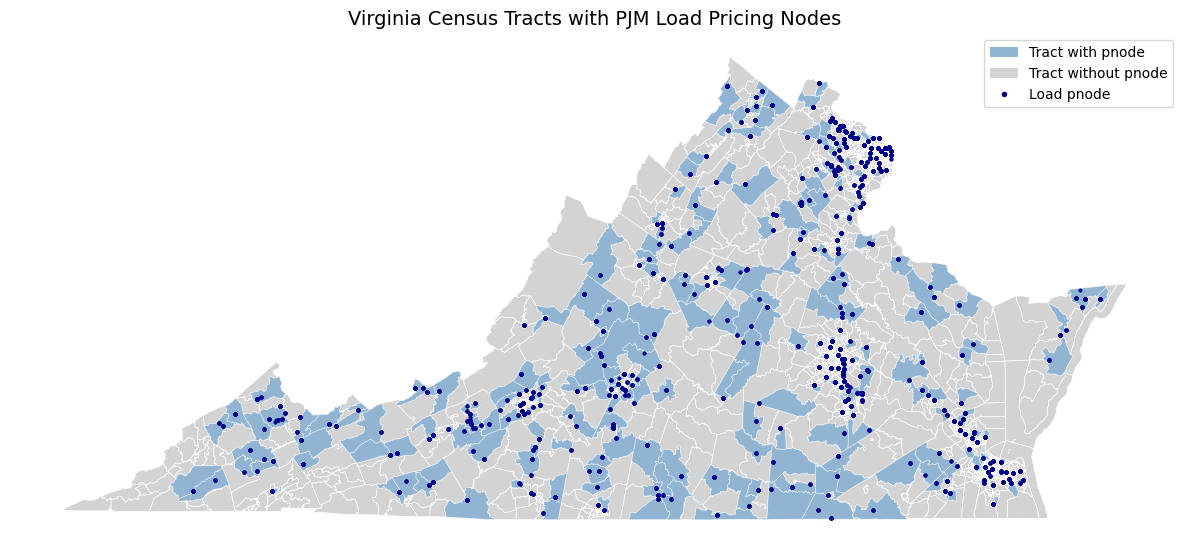

In [39]:
# Map to visualise
import matplotlib.pyplot as plt                                                                                                                                                        
                                                                                                                                                                                        
# Get GEOIDs that have at least one pnode                                                                                                                                              
tracts_with_pnodes = set(merged_with_tract["GEOID"].dropna())                                                                                                                          
census["has_pnode"] = census["GEOID"].isin(tracts_with_pnodes)                                                                                                                         
                
fig, ax = plt.subplots(1, 1, figsize=(12, 10))                                                                                                                                         
                
# Plot tracts, coloured by whether they have a pnode                                                                                                                                   
census[~census["has_pnode"]].plot(ax=ax, color="lightgrey", edgecolor="white", linewidth=0.5)
census[census["has_pnode"]].plot(ax=ax, color="steelblue", edgecolor="white", linewidth=0.5, alpha=0.6)                                                                                
                                                                                                                                                                                        
# Overlay pnode points                                                                                                                                                                 
merged_geo.plot(ax=ax, color="darkblue", markersize=3, alpha=0.8)                                                                                                                      
                                                                                                                                                                                        
ax.set_title("Virginia Census Tracts with PJM Load Pricing Nodes", fontsize=14)                                                                                                        
ax.set_axis_off()                                                                                                                                                                      
                                                                                                                                                                                        
# Manual legend 
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_elements = [                                                                                                                                                                    
    Patch(facecolor="steelblue", alpha=0.6, label="Tract with pnode"),
    Patch(facecolor="lightgrey", label="Tract without pnode"),                                                                                                                         
    Line2D([0], [0], marker="o", color="w", markerfacecolor="darkblue", markersize=5, label="Load pnode")                                                                              
]                                                                                                                                                                                      
ax.legend(handles=legend_elements, loc="upper right")                                                                                                                                  
                                                                                                                                                                                        
plt.tight_layout()
plt.show()

In [30]:
# Save final output
merged_with_tract = merged_with_tract.rename(columns={"GEOID": "census_geoid", "NAME": "census_name"})
merged_with_tract.to_csv(processed_dir / "va_lmp_yearly_avg_load_geo.csv", index=False)
print(f"Saved {len(merged_with_tract):,} rows to va_lmp_yearly_avg_load_geo.csv")

Saved 8,886 rows to va_lmp_yearly_avg_load_geo.csv


The file va_lmp_yearly_avg_load_geo.csv contains a table with one row per pnode per year it has pricing information (from 2015-2025), containing:

- The node's ID, name, and average hourly LMP components for that year (total, energy, congestion, loss)                                                                               
- The node's physical coordinates (lat lon)                                                                                                          
- The census tract it falls within (census_geoid, census_name) - based on the 2016 Census Tract boundaries